<center>

$\Huge \textbf{Universidad Nacional Autónoma de México}$  
$\Huge \textbf{Facultad de Ciencias}$  
<p align="center">
  <img src="https://www.icat.unam.mx/wp-content/uploads/2021/11/Copia-de-LogoUNAM.-Azul.-Fondo-transparente.png" alt="UNAM" width="200"/>
</p>

<hr style="height:3px; background-color:#0B6E4F; border:none;"/>


$\LARGE \textbf{Inteligencia Artificial}$  

$\Large \textit{Laboratorio 2.10}$  


\begin{array}{rl}
\textbf{Docente:} & Dra. Jessica Sarahi Méndez Rincón \\[6pt]
\textbf{Alumno:} & Jiménez Rivera Emiliano Kaleb \\[6pt]
\textbf{Fecha de realización:} & 29/04/2026
\end{array}

</center>

***
**UNAM no guarda relación alguna con las marcas mencionadas como ejemplo. Las marcas son propiedad de sus titulares conforme a la legislación aplicable, se utilizan con fines académicos y didácticos, por lo que no existen fines de lucro, relación publicitaria o de patrocinio.

---

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from random import randint
from time import sleep
from IPython.display import clear_output
from math import ceil,floor

%matplotlib inline

# Clase Agente

In [ ]:
class PongAgent:

    def __init__(self, game, policy=None, discount_factor = 0.1, learning_rate = 0.1, ratio_explotacion = 0.9):

        # Creamos la tabla de politicas
        if policy is not None:
            self._q_table = policy
        else:
            position = list(game.positions_space.shape)
            position.append(len(game.action_space))
            self._q_table = np.zeros(position)

        self.discount_factor = discount_factor
        self.learning_rate = learning_rate
        self.ratio_explotacion = ratio_explotacion

    def get_next_step(self, state, game):

        # Damos un paso aleatorio...
        next_step = np.random.choice(list(game.action_space))

        # o tomaremos el mejor paso...
        if np.random.uniform() <= self.ratio_explotacion:
            # tomar el maximo
            idx_action = np.random.choice(np.flatnonzero(
                    self._q_table[state[0],state[1],state[2]] == self._q_table[state[0],state[1],state[2]].max()
                ))
            next_step = list(game.action_space)[idx_action]

        return next_step

    # actualizamos las politicas con las recompensas obtenidas
    def update(self, game, old_state, action_taken, reward_action_taken, new_state, reached_end):
        idx_action_taken =list(game.action_space).index(action_taken)

        actual_q_value_options = self._q_table[old_state[0], old_state[1], old_state[2]]
        actual_q_value = actual_q_value_options[idx_action_taken]

        future_q_value_options = self._q_table[new_state[0], new_state[1], new_state[2]]
        future_max_q_value = reward_action_taken  +  self.discount_factor*future_q_value_options.max()
        if reached_end:
            future_max_q_value = reward_action_taken #maximum reward

        self._q_table[old_state[0], old_state[1], old_state[2], idx_action_taken] = actual_q_value + \
                                              self.learning_rate*(future_max_q_value -actual_q_value)

    def print_policy(self):
        for row in np.round(self._q_table,1):
            for column in row:
                print('[', end='')
                for value in column:
                    print(str(value).zfill(5), end=' ')
                print('] ', end='')
            print('')

    def get_policy(self):
        return self._q_table

# Clase Environment

In [ ]:
class PongEnvironment:

    def __init__(self, max_life=3, height_px = 40, width_px = 50, movimiento_px = 3):

        self.action_space = ['Arriba','Abajo']

        self._step_penalization = 0

        self.state = [0,0,0]

        self.total_reward = 0

        self.dx = movimiento_px
        self.dy = movimiento_px

        filas = ceil(height_px/movimiento_px)
        columnas = ceil(width_px/movimiento_px)

        self.positions_space = np.array([[[0 for z in range(columnas)]
                                                  for y in range(filas)]
                                                     for x in range(filas)])

        self.lives = max_life
        self.max_life=max_life

        self.x = randint(int(width_px/2), width_px)
        self.y = randint(0, height_px-10)

        self.player_alto = int(height_px/4)

        self.player1 = self.player_alto  # posic. inicial del player

        self.score = 0

        self.width_px = width_px
        self.height_px = height_px
        self.radio = 2.5

    def reset(self):
        self.total_reward = 0
        self.state = [0,0,0]
        self.lives = self.max_life
        self.score = 0
        self.x = randint(int(self.width_px/2), self.width_px)
        self.y = randint(0, self.height_px-10)
        return self.state

    def step(self, action, animate=False):
        self._apply_action(action, animate)
        done = self.lives <=0 # final
        reward = self.score
        reward += self._step_penalization
        self.total_reward += reward
        return self.state, reward , done

    def _apply_action(self, action, animate=False):

        if action == "Arriba":
            self.player1 += abs(self.dy)
        elif action == "Abajo":
            self.player1 -= abs(self.dy)

        self.avanza_player()

        self.avanza_frame()

        if animate:
            clear_output(wait=True);
            fig = self.dibujar_frame()
            plt.show()

        self.state = (floor(self.player1/abs(self.dy))-2, floor(self.y/abs(self.dy))-2, floor(self.x/abs(self.dx))-2)

    def detectaColision(self, ball_y, player_y):
        if (player_y+self.player_alto >= (ball_y-self.radio)) and (player_y <= (ball_y+self.radio)):
            return True
        else:
            return False

    def avanza_player(self):
        if self.player1 + self.player_alto >= self.height_px:
            self.player1 = self.height_px - self.player_alto
        elif self.player1 <= -abs(self.dy):
            self.player1 = -abs(self.dy)

    def avanza_frame(self):
        self.x += self.dx
        self.y += self.dy
        if self.x <= 3 or self.x > self.width_px:
            self.dx = -self.dx
            if self.x <= 3:
                ret = self.detectaColision(self.y, self.player1)

                if ret:
                    self.score = 10
                else:
                    self.score = -10
                    self.lives -= 1
                    if self.lives>0:
                        self.x = randint(int(self.width_px/2), self.width_px)
                        self.y = randint(0, self.height_px-10)
                        self.dx = abs(self.dx)
                        self.dy = abs(self.dy)
        else:
            self.score = 0

        if self.y < 0 or self.y > self.height_px:
            self.dy = -self.dy

    def dibujar_frame(self):
        fig = plt.figure(figsize=(5, 4))
        a1 = plt.gca()
        circle = plt.Circle((self.x, self.y), self.radio, fc='slategray', ec="black")
        a1.set_ylim(-5, self.height_px+5)
        a1.set_xlim(-5, self.width_px+5)

        rectangle = plt.Rectangle((-5, self.player1), 5, self.player_alto, fc='gold', ec="none")
        a1.add_patch(circle);
        a1.add_patch(rectangle)
        #a1.set_yticklabels([]);a1.set_xticklabels([]);
        plt.text(4, self.height_px, "SCORE:"+str(self.total_reward)+"  LIFE:"+str(self.lives), fontsize=12)
        if self.lives <=0:
            plt.text(10, self.height_px-14, "GAME OVER", fontsize=16)
        elif self.total_reward >= 1000:
            plt.text(10, self.height_px-14, "YOU WIN!", fontsize=16)
        return fig

# Juego

In [ ]:
def play(rounds=5000, max_life=3, discount_factor = 0.1, learning_rate = 0.1,
         ratio_explotacion=0.9,learner=None, game=None, animate=False):

    if game is None:
        # si usamos movimiento_px = 5 creamos una tabla de politicas de 8x10
        # si usamos movimiento_px = 3 la tabla sera de 14x17
        game = PongEnvironment(max_life=max_life, movimiento_px = 3)

    if learner is None:
        print("Begin new Train!")
        learner = PongAgent(game, discount_factor = discount_factor,learning_rate = learning_rate, ratio_explotacion= ratio_explotacion)

    max_points= -9999
    first_max_reached = 0
    total_rw=0
    steps=[]

    for played_games in range(0, rounds):
        state = game.reset()
        reward, done = None, None

        itera=0
        while (done != True) and (itera < 3000 and game.total_reward<=1000):
            old_state = np.array(state)
            next_action = learner.get_next_step(state, game)
            state, reward, done = game.step(next_action, animate=animate)
            if rounds > 1:
                learner.update(game, old_state, next_action, reward, state, done)
            itera+=1

        steps.append(itera)

        total_rw+=game.total_reward
        if game.total_reward > max_points:
            max_points=game.total_reward
            first_max_reached = played_games

        if played_games %500==0 and played_games >1 and not animate:
            print("-- Partidas[", played_games, "] Avg.Puntos[", int(total_rw/played_games),"]  AVG Steps[", int(np.array(steps).mean()), "] Max Score[", max_points,"]")

    if played_games>1:
        print('Partidas[',played_games,'] Avg.Puntos[',int(total_rw/played_games),'] Max score[', max_points,'] en partida[',first_max_reached,']')

    #learner.print_policy()

    return learner, game

In [ ]:
learner, game = play(rounds=5000, discount_factor = 0.2, learning_rate = 0.1, ratio_explotacion=0.85)

Begin new Train!
-- Partidas[ 500 ] Avg.Puntos[ 3 ]  AVG Steps[ 183 ] Max Score[ 140 ]
-- Partidas[ 1000 ] Avg.Puntos[ 15 ]  AVG Steps[ 221 ] Max Score[ 170 ]
-- Partidas[ 1500 ] Avg.Puntos[ 20 ]  AVG Steps[ 241 ] Max Score[ 240 ]
-- Partidas[ 2000 ] Avg.Puntos[ 24 ]  AVG Steps[ 253 ] Max Score[ 240 ]
-- Partidas[ 2500 ] Avg.Puntos[ 27 ]  AVG Steps[ 263 ] Max Score[ 410 ]
-- Partidas[ 3000 ] Avg.Puntos[ 28 ]  AVG Steps[ 267 ] Max Score[ 410 ]
-- Partidas[ 3500 ] Avg.Puntos[ 31 ]  AVG Steps[ 276 ] Max Score[ 410 ]
-- Partidas[ 4000 ] Avg.Puntos[ 33 ]  AVG Steps[ 283 ] Max Score[ 410 ]
-- Partidas[ 4500 ] Avg.Puntos[ 35 ]  AVG Steps[ 289 ] Max Score[ 410 ]
Partidas[ 4999 ] Avg.Puntos[ 35 ] Max score[ 410 ] en partida[ 2316 ]


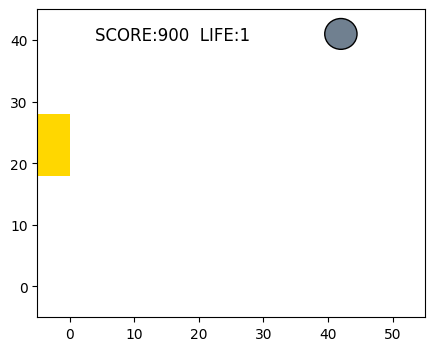

In [ ]:
learner2 = PongAgent(game, policy=learner.get_policy())
learner2.ratio_explotacion = 1.0  # con esto quitamos las elecciones aleatorias al jugar
player = play(rounds=1, learner=learner2, game=game, animate=True)

#Desafio

Prueba con diferentes cantidades de epoca así como con más o menos vidas. Elabora cuando hay mejor rendimiento, puedes usar las funciones de tiempo que se vieron en prácticas pasadas del laboratorio

In [ ]:
#usaremos los mismos hiperparametros que la practica
from time import perf_counter

discount_factor = 0.2
learning_rate = 0.1
ratio_explotation = 0.9

epocas = [500, 1000, 2500, 5000]
vidas = [1, 3, 5]
partidas_eval = 100


def evaluar(learner, partidas=partidas_eval, max_life=3):
  """evaluamos algo que ya fue entrenado y regresamos medias y maximo de puntos"""
  game_eval = PongEnvironment(max_life = max_life, movimiento_px=3)
  agente = PongAgent(game_eval, policy=learner.get_policy().copy())
  agente.ratio_explotacion = 1.0
  puntos = []

  for _ in range (partidas):
    state = game_eval.reset()
    done, itera = False, 0
    while not done and itera < 3000 and game_eval.total_reward <= 1000:
      accion = agente.get_next_step(state, game_eval)
      state, reward, done = game_eval.step(accion)
      itera += 1

    puntos.append(game_eval.total_reward)
  return np.mean(puntos), np.max(puntos)


resultados = []

for n_vidas in vidas:
  for n_epocas in epocas:
    inicio = perf_counter()
    learner_exp, _ = play(
        rounds=n_epocas, max_life=n_vidas,
        discount_factor=discount_factor,
        learning_rate=learning_rate,
        ratio_explotacion= ratio_explotation
    )

    tiempo = perf_counter() - inicio

    #aqui evaluamos con 3 vidas
    prom, maximo = evaluar(
        learner_exp, partidas_eval,
        max_life=3
    )
    resultados.append((n_vidas, n_epocas, tiempo, prom, maximo))
    print(f"Vidas={n_vidas} Epocas={n_epocas} Tiempo={tiempo:.1}s")
    print(f"Prom.eval={prom:.1f} Max.eval={maximo}")

Begin new Train!
Partidas[ 499 ] Avg.Puntos[ -2 ] Max score[ 70 ] en partida[ 75 ]
Vidas=1 Epocas=500 Tiempo=2e+00s
Prom.eval=2.9 Max.eval=110
Begin new Train!
-- Partidas[ 500 ] Avg.Puntos[ -2 ]  AVG Steps[ 47 ] Max Score[ 90 ]
Partidas[ 999 ] Avg.Puntos[ 3 ] Max score[ 180 ] en partida[ 688 ]
Vidas=1 Epocas=1000 Tiempo=5e+00s
Prom.eval=26.1 Max.eval=120
Begin new Train!
-- Partidas[ 500 ] Avg.Puntos[ -3 ]  AVG Steps[ 44 ] Max Score[ 80 ]
-- Partidas[ 1000 ] Avg.Puntos[ 0 ]  AVG Steps[ 53 ] Max Score[ 80 ]
-- Partidas[ 1500 ] Avg.Puntos[ 1 ]  AVG Steps[ 59 ] Max Score[ 110 ]
-- Partidas[ 2000 ] Avg.Puntos[ 3 ]  AVG Steps[ 66 ] Max Score[ 150 ]
Partidas[ 2499 ] Avg.Puntos[ 4 ] Max score[ 150 ] en partida[ 1991 ]
Vidas=1 Epocas=2500 Tiempo=1e+01s
Prom.eval=76.3 Max.eval=220
Begin new Train!
-- Partidas[ 500 ] Avg.Puntos[ -1 ]  AVG Steps[ 49 ] Max Score[ 80 ]
-- Partidas[ 1000 ] Avg.Puntos[ 1 ]  AVG Steps[ 58 ] Max Score[ 170 ]
-- Partidas[ 1500 ] Avg.Puntos[ 3 ]  AVG Steps[ 67 ] Max Sco

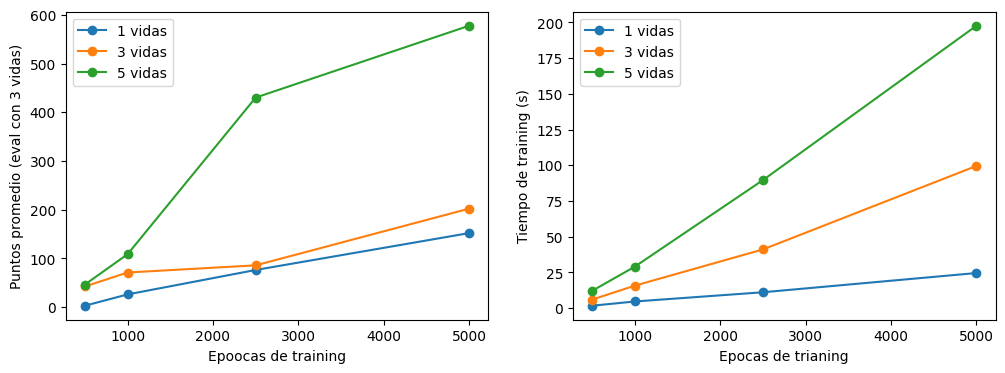

In [ ]:
#ahora podriamos graficar todo el rendimeinto y tiempos

res = np.array(resultados)
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12, 4))
for n_vidas in vidas:
  sub = res[res[:, 0] == n_vidas]
  ax1.plot(sub[:, 1], sub[:, 3], marker="o", label=f"{n_vidas} vidas")
  ax2.plot(sub[:, 1], sub[:, 2], marker="o", label=f"{n_vidas} vidas")

ax1.set_xlabel("Epoocas de training")
ax1.set_ylabel("Puntos promedio (eval con 3 vidas)")
ax2.set_xlabel("Epocas de trianing")
ax2.set_ylabel("Tiempo de training (s)")
ax1.legend()
ax2.legend()
plt.show()

Ahora sí con los resultados podemos ver que más épocas en este caso siempre mejoraron el rendimiento (no podría decir si estamos viendo un overfitting), sin importar el número de vidas. Pues con una sola vida el promedio en la evaluación pasó de 2.9 puntos con 500 épocas a 152.0 con 5000, y con tres vidas subió de 42.4 a 85.5 entre 500 y 2500 épocas. Sin embargo, lo que más contrastó o remarcó esta diferencia fue entrenar con más vidas según la gráfica. Nuestro mejor experimento fue el de 5000 épocas con 575 puntos. Y es que sí, lo que hizo la diferencia fueron la cantidad de vidas, pues mientras con una vida cada partida duró entre 44 y 77 pasos, la de tres vidas duró entre 229 y 327. Podemos pensarlo como que nuestras vidas gastadas fueron un gran castigo para que el modelo fuese aprendiendo más rápido. Por otro lado si comparamos por tiempo invertido, cinco vidas nos conviene más: con 2500 épocas tuvimos aprox 90 segundos, que superó por mucho a tres vidas con 5000 épocas que se tardó entre unos 100s y con 200 puntos. Por útlimo, me di cuenta que tomar los máximos de puntos no fue una buena métrica para resumir la información, sino la media que nos dice más o menos que modelo (con su número de épocas) nos conviene más. Fue algo divertido usar matplotlib para ir comparando por medio de plots sencillos.

#Conclusiones finales del estudiante

En estra práctica pudimos implementar y usar metodologías sobre aprendizaje de máquina, i.e. aquí fue más evidente cómo es que con cada fallo y recompoensa el agente jugador iba mejorando. El problema estuvo dividido en dos clases el PongEnvironment que funciona como ambiente y entrega estados, recompensas y señales a nuestro agente mediante reset() o step(). Por su parte PongAgent es el encargado de recibir estas señales e ir maximiznado sus chances de ganar o de no hacer reset() tan pronto, es la misma arquitectura que vimos en el primer parcial, donde un agente convive con su entorno y este ambiente es el que envía señales que después son procesadas por el agente.

Algunas cosas que me parecieron interesantes es que en el método de update se aplicaba la función de Bellman usando discount_factor y learning_rate, mientras que había una variable que nos controlaba el balance entre explorar y explotar (i.e. morir) que fue el ratio_explotacion.

Con la ejecución de una sola partida me di cuenta que era una cantidad muy peuqeña de partidas (casi nula) para que una gente pudiera rendir muy bien en un test, pues todavía no aprendía lo suficiente. A diferencia de los algoritmos que vimos en anteriores prácticas, este no conoce de antemano un modelo de transiciones. Lo aprende a base de prueba y error con las respectivas recompensas que fueron +10 o -10. Fue una bonita vista de lo que se avecina en futuras prácticas y cómo es que de forma análoga fue evolucionando la inteligencia artificial en todo ámbito, incluyendo los videojuegos que pudieron lucirse aquí.

<hr/>
<footer style="text-align:center; font-size:12px; color:gray;">
© 2026 UNAM Facultado de Ciencias – Todos los derechos reservados

</footer>